In [4]:
# WARNING будет загружен датасет и сами модели
!dvc pull

ERROR: failed to pull data from the cloud - Can't remove the following unsaved files without confirmation. Use `--force` to force.
C:\Users\WorkStation\PycharmProjects\psychic-spoon\dataset\Arts_Crafts_and_Sewing_5.json
C:\Users\WorkStation\PycharmProjects\psychic-spoon\dataset\Arts_Crafts_and_Sewing.csv
C:\Users\WorkStation\PycharmProjects\psychic-spoon\models\Image2Caption.pt


# Результаты

Визуально график выглядит стационарным и показывает аддитивную сезонность без тренда. Тест Дики-Фуллера показывает стационарность ряда.

Однако, для более точного и полного разложения ряда необходимо больше погрузиться в математическую основу временных рядов.

1. _Все значения ошибок округлены до целых значений путем удаления дробной части_
1. _Обучение происходило на 5 фолдах 4-х недельной обучающей выборки и проверялось на 2-х неделях (если не сказано иное)_


- Ошибка базового прогноза по средним значениям составила: ~108_601
- ARIMA (statsmodels) (если предсказывать по всем обучающим данным): ~130_797
- ARIMA (statsmodels) (лучшая модель на обучении): ~56_722
- ARIMA (statsmodels) (если предсказывать лучшей моделью на обучении): ~10_597_095

Однако, здесь есть небольшое упущение. Валидационные данные это последние две недели, а тестовые данные это следующий фолд.

Между ними есть опеределенный промежуток времени и если мы посмотрим на график, то увидим что модель предсказывает +- верно, но не совпадает по времени. Поэтому такой прогноз некорректен, но правилен (насколько можно это сказать)

- ARIMA (nixtla) (внутренняя ошибка переполнения): +inf
- Random Forest (без температуры): ~103_910
- Gradient Boosting (sklearn) (без температуры): ~94_084

В данном датасете данные хоть и идут по временному ряду. Но они особо не изменяются со временем (да есть недельная сезонность, но не более). По этой причине они достаточно хорошо разбираются базовыми алгоритмами классического машинного обучения (хоть и ушли не сильно далеко от простого среднего).


In [29]:
import warnings
import json

from pandas import DataFrame
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsforecast.models as nixtla
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.utils.validation import check_is_fitted
from statsforecast import StatsForecast
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from sklearn.exceptions import NotFittedError
import json

warnings.filterwarnings("ignore")


In [16]:
from tqdm import tqdm
import holidays

n_factors = 10

with open("./dataset/Arts_Crafts_and_Sewing_5.json", "r") as data_file:
    data_lines = [json.loads(raw_data) for raw_data in data_file.readlines()]
    data = pd.DataFrame(data_lines)

data = data[:1000]

data.loc[:, 'reviewTime'] = pd.to_datetime(data['unixReviewTime'], unit='s')
data.drop(columns=["style", "reviewText", "summary", "image", "reviewerName", "unixReviewTime", "vote", "verified"],
          inplace=True)
data = data.sort_values(by=['reviewTime'], ascending=True)

# Удаление дублей
# print("Дубликатов записей:", len(data[data["date_time"].duplicated()]))
# data.drop_duplicates(subset="date_time", keep="last", inplace=True)
# print('=' * 15)

# Изменяем дату из строки в объект
# data["date_time"] = pd.to_datetime(data["date_time"])

# Заполняем пропущенные даты
# full_range = pd.date_range(start=data["date_time"].min(), end=data["date_time"].max(), freq='1h')
# missed_timestamps = full_range.difference(data["date_time"])
# holidays = [holidays.US().get(date) for date in missed_timestamps]


print(data.info())
print('=' * 15)
print(data.describe())
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 208 to 632
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   overall     1000 non-null   float64
 1   reviewTime  1000 non-null   object 
 2   reviewerID  1000 non-null   object 
 3   asin        1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 39.1+ KB
None
          overall
count  1000.00000
mean      4.58200
std       0.91876
min       1.00000
25%       5.00000
50%       5.00000
75%       5.00000
max       5.00000


,overall,reviewTime,reviewerID,asin
208,3.0,2007-05-09 00:00:00,A3PQP4FDHZ9258,1584799684
437,5.0,2007-07-28 00:00:00,A2ZAORLQI9CV8V,B00000J3LY
46,5.0,2007-08-03 00:00:00,A2H8F55EZZ89TO,0823013626
598,5.0,2007-08-29 00:00:00,A2GYPI82BWZCOS,B0000302YN
45,5.0,2008-01-29 00:00:00,A2FFKM8WHUHVTU,0823013626


In [7]:
print(f'количество пользователей = {data["reviewerID"].nunique()}')
print(f'количество пользователей = {data["reviewerID"].nunique()}')
print(f'количество объектов = {data["asin"].nunique()}')
print(f"количество рейтингов = {(~data['overall'].isna()).sum()}")

количество пользователей = 952
количество пользователей = 952
количество объектов = 48
количество рейтингов = 1000


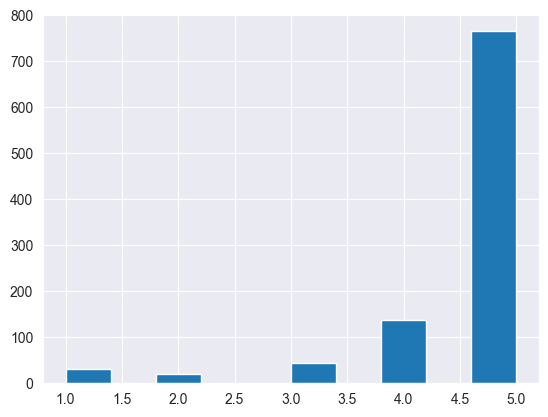

In [8]:
data['overall'].hist(bins=10);

In [13]:
def most_popular_predict(data: DataFrame, n=10):
    grouped = data[["asin", "overall", ]].groupby(by=["asin"]).agg(["mean", "count"])
    sorted_data = grouped.reset_index().sort_values([("overall", "count"), ("overall", "mean")], ascending=False)
    return sorted_data.iloc[:n]["asin"].to_list()


X = data.copy(deep=True)
y = data["asin"]

hr_n_train = []
hr_n_test = []
loo = LeaveOneOut()
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    predicted = most_popular_predict(X_train, n_factors)
    result = y_train.map(lambda x: x in predicted)
    hr_n = sum(result) / len(result)
    hr_n_train.append(hr_n)

    result = y_test.map(lambda x: x in predicted)
    hr_n = sum(result) / len(result)
    hr_n_test.append(hr_n)

print(f"HR n (train): {np.mean(hr_n_train)}")
print(f"HR n (test): {np.mean(hr_n_test)}")

HR n (train): 0.6580000000000003
HR n (test): 0.658


In [43]:
X = data.copy(deep=True)

y = X[["reviewerID", "asin"]]


def find_top_items(U, Vt, user_id, item_ids, n_top_items):
    predictions = U[user_id] @ Vt
    recommendations = pd.DataFrame({
        'item_id': item_ids,
        'predicted_rating': predictions
    }).sort_values('predicted_rating', ascending=False)
    return recommendations['item_id'].head(n_top_items)


hr_n_train = []
hr_n_test = []
loo = LeaveOneOut()
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    user_encoder = LabelEncoder()
    X_train["users"] = user_encoder.fit_transform(X['reviewerID'])

    item_encoder = LabelEncoder()
    X_train["items"] = item_encoder.fit_transform(X['asin'])

    item_ids = item_encoder.inverse_transform(range(X["items"].nunique()))

    R = X_train.pivot_table(index="users", columns="items", values="overall", aggfunc="mean")
    R = R.fillna(0)

    svd = TruncatedSVD(n_components=n_factors, random_state=42)
    U = svd.fit_transform(R)
    Vt = svd.components_
    apply_func = lambda x: x["asin"] in find_top_items(U, Vt, user_encoder.transform([x["reviewerID"]])[0],
                                                       item_ids, n_factors)
    result = y_train.apply(apply_func, axis=1)
    hr_n = sum(result) / len(result)
    hr_n_train.append(hr_n)

    # result = y_test.apply(apply_func, axis=1)
    # hr_n = sum(result) / len(result)
    # hr_n_test.append(hr_n)

print(f"HR n (train): {np.mean(hr_n_train)}")
# print(f"HR n (test): {np.mean(hr_n_test)}")

KeyboardInterrupt: 